# Crash stats — ΔP, i_c, Δt, recovery (Phase 3a)

Tee & Ting §4.2–4.3. Sample: HL+Deribit+Kraken · ETH+BTC · 2026-09-04…10.


## Theory → method

Paper event stats: \(\Delta P\), \(i_c\) (ticks→**trades**), \(\Delta t\), recovery.
Phase 2 raw SSM z*=6 = 3668 micro-outliers → **severity gate** \(|\Delta P|\ge10\) bps, \(i_c\ge5\) → **275**.



In [1]:
from pathlib import Path
import json
OUT = Path('../../out/phase3a_stats_xsec').resolve()
s = json.loads((OUT / 'phase3a_summary.json').read_text())
p = s['pooled']
print('cells', p['n_cells'], 'raw', p['n_ssm_raw'], 'gated', p['n_ssm_gated'], 'nanex', p['n_nanex'])
print('gate', p.get('gate_ablation_totals'))
print('ssm_dp', p['ssm_dp'])
print('class', p['ssm_class'])
print('markout', p.get('ssm_markout_mean_bps'))
print('dt_mo', p.get('spearman_dt_mo5_cell_mean'))
print('ols', s.get('ols_event', {}).get('dp', {}).get('r2'))
print('vpin_int', (s.get('ols_event', {}).get('dp', {}) or {}).get('with_vpin_interaction', {}).get('r2'))
print('time_split', s.get('time_split'))
print('exante', s.get('ols_exante'))
print('multi_coin', s.get('multi_coin'))
print('by_venue', s.get('by_venue'))



cells=42 ssm_raw=3668 gated=275 nanex=105
gate_ablation={'5bps_ic3': {'n_raw': 3668, 'n_kept': 589}, '10bps_ic5': {'n_raw': 3668, 'n_kept': 275}, '30bps_ic10': {'n_raw': 3668, 'n_kept': 56}}
ssm_dp={'n': 275, 'mean': 0.2338371657581987, 'median': 0.17692265162824378, 'sd': 0.1500445577278157, 'p25': 0.12979357030011185, 'p75': 0.2827174869607355}
ssm_class={'n_v_recovery': 212, 'n_continuation': 39, 'n_partial': 24, 'share_v': 0.7709090909090909, 'share_continuation': 0.14181818181818182}
markout={'0.5': -4.8529595645259205, '1.0': -7.633413298911545, '5.0': -7.12819350000448}
dt_mo_spearman=-0.276027499975911
ols_r2=0.01957550628826421 vpin_r2=0.03504955813928645
time_split={'early_n': 165, 'late_n': 110, 'early_beta_logN': 0.0010321979810437483, 'late_beta_logN': -0.008326975452582236, 'early_r2': 0.042950682511061045, 'late_r2': 0.026725177569318914, 'sign_stable': 0}
exante_n=20 exante_r2=0.17508963952096224
multi_coin={'ETH': {'n_cells': 15, 'mean_median_dp': 0.19336934836180145, 

## Severity gate


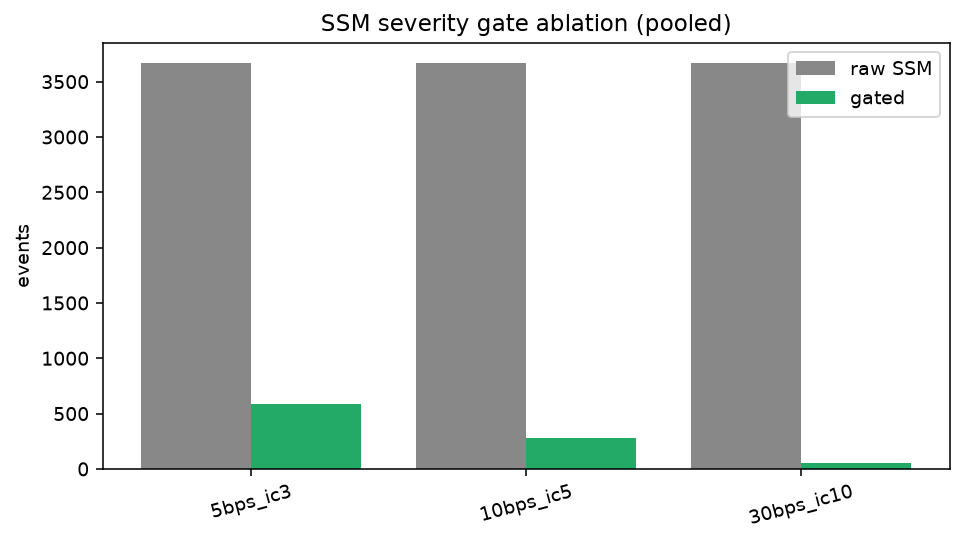

In [2]:
from IPython.display import Image
Image(filename=str(OUT/'figs/fig_severity_gate.png'))


## ΔP distribution (Nanex vs gated SSM)


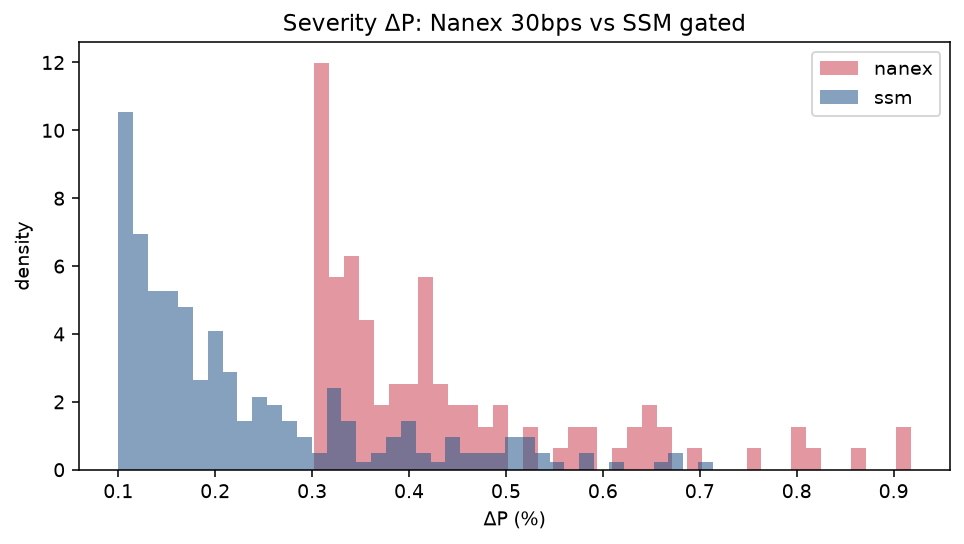

In [3]:
Image(filename=str(OUT/'figs/fig_dp_hist.png'))


## Signal board — V vs continuation


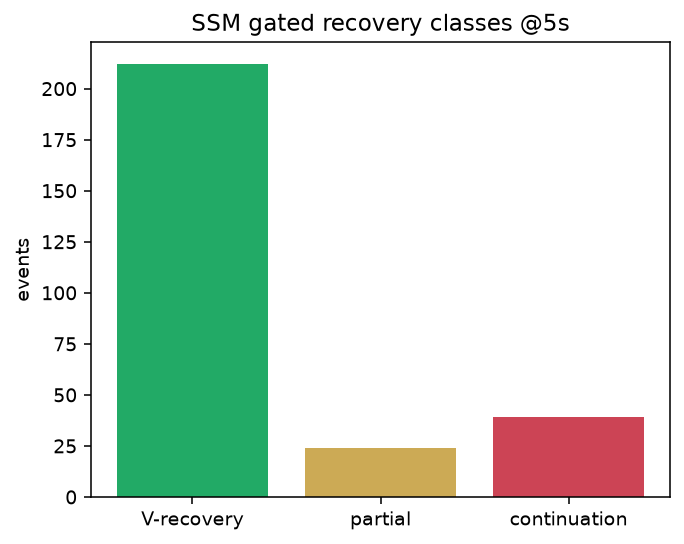

In [4]:
Image(filename=str(OUT/'figs/fig_recovery_class.png'))


### Interpretation
- Gated median ΔP≈**0.18%**, Nanex≈**0.40%**.
- Recovery class: **77% V** @5s; tape markout ≈**−7 bps** @5s → mean-revert / liquidity hole.
- Duration–|markout| Spearman≈**−0.28** (Hold as risk feature; calendar Δt median 0).
- **Promote:** `risk.ssm_severity_gate_10bps`, `info.crash_v_vs_continuation`.
- **Kill:** ungated SSM counts as risk intensity.

